# Dynex SDK - nBit Adder Native Gate Circuit Example

First we import the required packages:

In [1]:
from pennylane import numpy as np
import pennylane as qml
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit:

In [2]:
params = [5432987654321098765, 7876543210987654321]  # two numbers to add


def Nqubits(a, b):
    mxVal = a + b
    return mxVal.bit_length()


wires = Nqubits(*params)


def Kfourier(k, wires):
    for j in range(len(wires)):
        qml.RZ(k * np.pi / (2 ** j), wires=wires[j])


def FullAdder(params, state=True):
    a, b = params
    wires = Nqubits(a, b)
    qml.BasisEmbedding(a, wires=range(wires))
    qml.QFT(wires=range(wires))
    Kfourier(b, range(wires))
    qml.adjoint(qml.QFT)(wires=range(wires))
    if state:
        return qml.state()
    else:
        return qml.sample()

We draw the circuit:

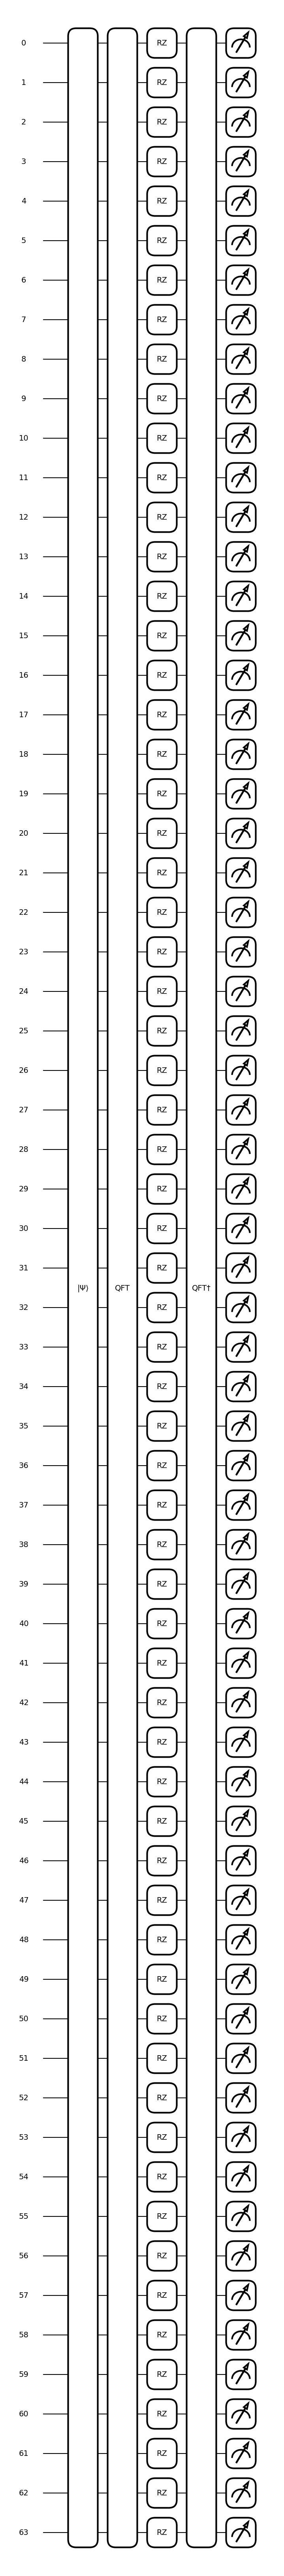

In [3]:
# draw circuit:
_ = qml.draw_mpl(FullAdder, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)
measure = dynex_circuit.execute(FullAdder, params, wires, method="measure",
                                num_reads=1, integration_steps=10)
print("Measure:", measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=1, shots=1, annealing_time=10
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7413)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': 0.7307496409655582, 'cos_rz_1': -0.9302552448026181, 'cos_rz_10': -0.16563679585415425, 'cos_rz_11': -0.6458959684600322, 'cos_rz_12': 0.42077549330965547, 'cos_rz_13': 0.8428450312215334, 'cos_rz_14': 0.9599075557629322, 'cos_rz_15': -0.9899261476905568, 'cos_rz_16': 0.07097130515019148, 'cos_rz_17': 0.7317688518754374, 'cos_rz_18': 0.9305291107416891, 'cos_rz_19': -0.9824787811300785, 'cos_rz_2': 0.1867414726264386, 'cos_rz_20': -0.09359812730477458, 'cos_rz_21': 0.6732020026319089, 'cos_rz_22': 0.9146589535537027, 'cos_rz_23': -0.97843215236257, 'cos_rz_24': 0.10384567308614746, '

Mesaure: [1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 0 0 1 1 1 0 0 0 0 1 1
 0 0 1 1 1 0 1 0 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0]


In [5]:
bitStr = "".join(map(str, measure.astype(int)))
dynexResult = int(bitStr, 2)
print("Dynex Result:", dynexResult)
print("Expected Result:", sum(params))
isValidDynex = dynexResult == sum(params)
print("Is Dynex Result Valid?", isValidDynex)

Dynex Result: 13309530865308753086
Expected Result: 13309530865308753086
Is Dynex Result Valid? True
